In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts_path = Path(analysis_directory.name) / 'counts.zarr'
analysis_path = Path(analysis_directory.name) / 'reuse_and_tracing.zarr'
repack_store(
    f'{dataset}/data.zarr',
    str(repacked_counts_path),
    nthreads=2,
)
ds = scarf.mount_datastore(
    str(repacked_counts_path),
    at=str(analysis_path),
    default_assay='RNA',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures'],
    highs=[15000, 4000],
    lows=[1000, 500],
    reset_previous=True,
)
# Remake HVGs after this tutorial's cell filter so lineage does not pull in a
# feature selection that was computed under an earlier cell mask on the store.
hvg_ref = ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/normalized//data: 1 / 1 complete

Repacking RNA/artifacts/mapping_reference//loadings: 1 / 1 complete

  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)


Calculating feature statistics: 30 / 30 complete

In [2]:
normalized = ds.run_normalization(
    features=hvg_ref,
    update_state=False,
)
pca = ds.run_pca(normalized, dims=15, update_state=False)
ann = ds.build_ann_index(pca, update_state=False)
neighbors_k11 = ds.query_neighbors(ann, k=11, update_state=False)
graph_k11 = ds.build_connectivity_map(neighbors_k11, update_state=False)

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [3]:
neighbors_k15 = ds.query_neighbors(ann, k=15, update_state=False)
graph_k15 = ds.build_connectivity_map(neighbors_k15, update_state=False)

print('normalization reused:', ds.run_normalization(features=hvg_ref, update_state=False) == normalized)
print('PCA reused:', ds.run_pca(normalized, dims=15, update_state=False) == pca)
print('ANN index reused:', ds.build_ann_index(pca, update_state=False) == ann)
print('neighbors recomputed:', neighbors_k15 != neighbors_k11)
print('graph recomputed:', graph_k15 != graph_k11)

Identifying neighbors: 1 / 1 complete

normalization reused: True


PCA reused: True
ANN index reused: True
neighbors recomputed: True
graph recomputed: True


edges (nnz): {'k11': 47960, 'k15': 65400}


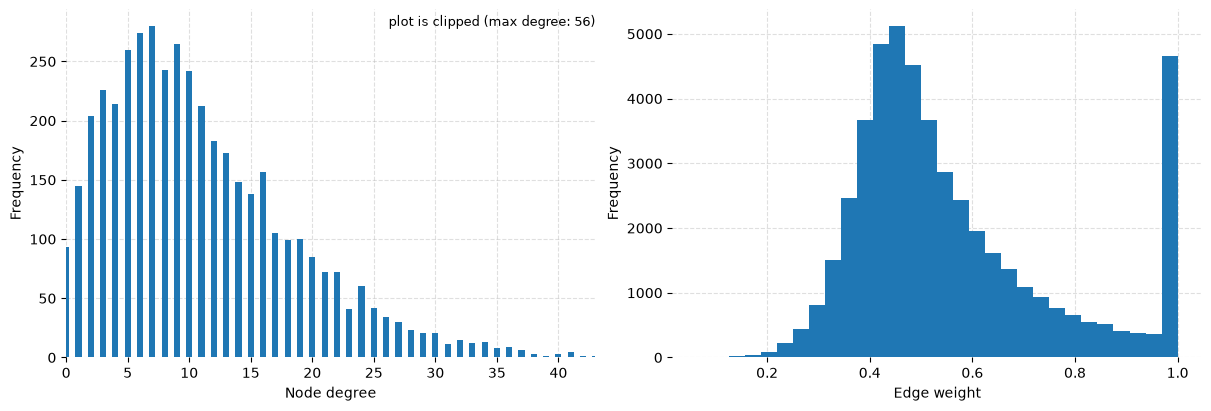

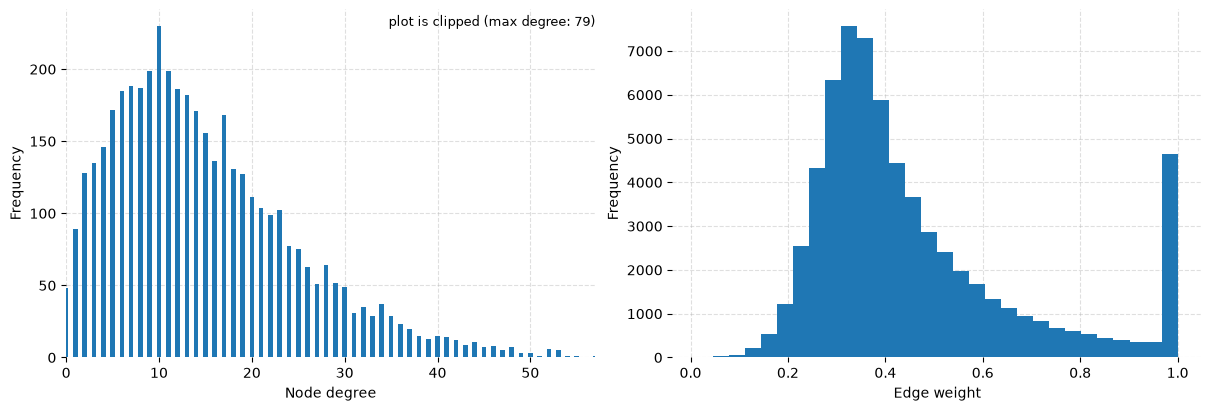

In [4]:
import scarf.plotting as splt

matrix_k11 = ds.load_graph(graph=graph_k11)
matrix_k15 = ds.load_graph(graph=graph_k15)
print('edges (nnz):', {'k11': matrix_k11.nnz, 'k15': matrix_k15.nnz})
splt.graph_qc(matrix_k11)
splt.graph_qc(matrix_k15)

In [5]:
pca_dims20 = ds.run_pca(normalized, dims=20, update_state=False)
ann_dims20 = ds.build_ann_index(pca_dims20, update_state=False)
neighbors_dims20 = ds.query_neighbors(ann_dims20, k=11, update_state=False)
graph_dims20 = ds.build_connectivity_map(neighbors_dims20, update_state=False)

print('PCA recomputed:', pca_dims20 != pca)
print('ANN index recomputed:', ann_dims20 != ann)
print('neighbors recomputed:', neighbors_dims20 != neighbors_k11)
print('graph recomputed:', graph_dims20 != graph_k11)
print('normalization reused:', ds.run_normalization(features=hvg_ref, update_state=False) == normalized)

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

PCA recomputed: True
ANN index recomputed: True
neighbors recomputed: True
graph recomputed: True
normalization reused: True


In [6]:
forced = ds.run_normalization(
    features=hvg_ref,
    update_state=False,
    invalidate_cache=True,
)
status = ds.inspect_artifact(forced)
baseline = ds.inspect_artifact(normalized)
baseline_inputs = baseline.inputs or {}
forced_inputs = status.inputs or {}

print('new artifact:', forced != normalized)
print('complete:', status.complete)
print('operation:', status.operation)
print('path:', status.path)
print('baseline path:', baseline.path)
print('same parameters:', status.parameters == baseline.parameters)
print('same input roles:', set(baseline_inputs) == set(forced_inputs))
print('same inputs:', forced_inputs == baseline_inputs)

Writing data: 1 / 1 complete

new artifact: True
complete: True
operation: run_normalization
path: RNA/artifacts/normalized/dda8339479f1633d066ec304b7422b40303a620b536f385f8b72d184313a254b
baseline path: RNA/artifacts/normalized/a165b04e8b6ad27227d36d0bed979c8033a971260f2eb72c977711d5ea9bfb53
same parameters: True
same input roles: True
same inputs: True


In [7]:
lineage = ds.lineage(
    {
        'k11 graph': graph_k11,
        'k15 graph': graph_k15,
        'dims20 graph': graph_dims20,
    }
)
lineage

```mermaid
flowchart LR
    artifact0["datastore / cell_selection | filter_cells | 4262751d6233"]
    artifact1["RNA / feature_summary | summarize_rna_features | c42371569f5c"]
    artifact2["RNA / feature_selection | mark_hvgs | 80f7f124add5"]
    artifact3["RNA / normalized | run_normalization | a165b04e8b6a"]
    artifact4["RNA / feature_scaling | calculate_feature_scaling | 3856ce0df288"]
    artifact5["RNA / reduction | run_pca | 6388171eb820"]
    artifact6["RNA / ann_index | build_ann_index | 1c6e7343c907"]
    artifact7["RNA / neighbors | query_neighbors | 4c56a1265236"]
    artifact8["RNA / connectivity_map | build_connectivity_map | c4fa553fd4e7 | outputs: k11 graph"]
    artifact9["RNA / neighbors | query_neighbors | 5c0e278170cc"]
    artifact10["RNA / connectivity_map | build_connectivity_map | a7c044521100 | outputs: k15 graph"]
    artifact11["RNA / reduction | run_pca | ff10578eed11"]
    artifact12["RNA / ann_index | build_ann_index | 2369174a8dc4"]
    artifact13["RNA / neighbors | query_neighbors | 7ea2b625de95"]
    artifact14["RNA / connectivity_map | build_connectivity_map | 5d070fc0cb95 | outputs: dims20 graph"]
    artifact0 -->|"cell_selection"| artifact1
    artifact9 -->|"neighbors"| artifact10
    artifact0 -->|"pca_cell_selection"| artifact11
    artifact3 -->|"normalized"| artifact11
    artifact4 -->|"feature_scaling"| artifact11
    artifact11 -->|"coordinates"| artifact12
    artifact11 -->|"coordinates"| artifact13
    artifact12 -->|"ann_index"| artifact13
    artifact13 -->|"neighbors"| artifact14
    artifact1 -->|"feature_summary"| artifact2
    artifact0 -->|"cell_selection"| artifact3
    artifact2 -->|"feature_selection"| artifact3
    artifact3 -->|"normalized"| artifact4
    artifact0 -->|"pca_cell_selection"| artifact5
    artifact3 -->|"normalized"| artifact5
    artifact4 -->|"feature_scaling"| artifact5
    artifact5 -->|"coordinates"| artifact6
    artifact5 -->|"coordinates"| artifact7
    artifact6 -->|"ann_index"| artifact7
    artifact7 -->|"neighbors"| artifact8
    artifact5 -->|"coordinates"| artifact9
    artifact6 -->|"ann_index"| artifact9
```

### Artifact details

#### datastore / cell_selection / 4262751d6233
- Status: `complete`
- Path: `artifacts/cell_selection/4262751d6233504ac6f36221e794a6c16acfbf3fbfcdae1e23837634e44a4d4a`
- Operation: `filter_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; highs=[15000,4000]; keep_bounds=false; lows=[1000,500]; reset_previous=true`
- Execution options: `source_column="I"`
- Other inputs: `metadata_fingerprints={"RNA_nCounts":"a8a7520000e32d28bcf97a8977290bcc7185570098e1fe95739c74687b435843","RNA_nFeatures":"a3df08addee7271194b0ebdfac85ad92ec93f3801031e65316776453eb...; ordered_row_ids_fingerprint="f5f05615ffc8833f75752b75152ccd728702f42950f81e9c28402880a4dd2ae5"; values_fingerprint="c56cd97011e0ca999890ff144c9e3b8c10121cd0ee887e0f69f9abd4512e68f2"`

#### RNA / feature_summary / c42371569f5c
- Status: `complete`
- Path: `RNA/artifacts/feature_summary/c42371569f5cd942839b00157d4592797e74e3784dfb697d595a0003db004856`
- Operation: `summarize_rna_features`
- Parameters: `normalization_method={"module":"scarf.assay","qualname":"norm_lib_size"}; size_factor=1000`
- Execution options: `nthreads=4`

#### RNA / feature_selection / 80f7f124add5
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/80f7f124add5960e3d32d0b765245b0f860ebe7409521b39711b09e7e824b8c8`
- Operation: `mark_hvgs`
- Parameters: `bin_strategy="adaptive"; blacklist="^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"; keep_bounds=false; lowess_frac=0.1; max_cells=4340; max_mean={"special_float":"inf"}; max_var={"special_float":"inf"}; min_cells=20; min_mean={"special_float":"-inf"}; min_var={"special_float":"-inf"}; n_bins=200; top_n=500`
- Execution options: `invalidate_cache=false; label="hvgs"; nthreads=4; plot_kwargs={}; show_plot=false`

#### RNA / normalized / a165b04e8b6a
- Status: `complete`
- Path: `RNA/artifacts/normalized/a165b04e8b6ad27227d36d0bed979c8033a971260f2eb72c977711d5ea9bfb53`
- Operation: `run_normalization`
- Parameters: `log_transform=true; normalization_method={"external_hook":true,"module":"scarf.assay","qualname":"norm_lib_size"}; renormalize_subset=true; size_factor=1000.0`
- Execution options: `cell_key="I"; from_assay="RNA"; invalidate_cache=false; update_state=false`

#### RNA / feature_scaling / 3856ce0df288
- Status: `complete`
- Path: `RNA/artifacts/feature_scaling/3856ce0df2883f0c24c88f8fd465f7d4d096cde943d710cad81de17058a0c23a`
- Operation: `calculate_feature_scaling`
- Parameters: `enabled=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"`

#### RNA / reduction / 6388171eb820
- Status: `complete`
- Path: `RNA/artifacts/reduction/6388171eb8201cd8d4796638364c573c373708ba58e63e4947fffc75af5f46ab`
- Operation: `run_pca`
- Parameters: `dims=15; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 1c6e7343c907
- Status: `complete`
- Path: `RNA/artifacts/ann_index/1c6e7343c907b24d4f1ec49507bac4ecc452e44576a1124b877b1955366b5cf5`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 4c56a1265236
- Status: `complete`
- Path: `RNA/artifacts/neighbors/4c56a12652362d7f58138cc788335604b6ef4f8759d895d12e37a0993cbcf3c4`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / c4fa553fd4e7
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/c4fa553fd4e79de80496351aa9901149483bbf6e7b272f29f9df606de6793b4b`
- Operation: `build_connectivity_map`
- Outputs: `k11 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / neighbors / 5c0e278170cc
- Status: `complete`
- Path: `RNA/artifacts/neighbors/5c0e278170cc43cd61098b00cc37ba8aa8b89805cf1e5f7f0224b33504d6a3c6`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=15`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / a7c044521100
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/a7c04452110095a9872be49eab0938c072c31d1f2429a96c3d2436d2b602963e`
- Operation: `build_connectivity_map`
- Outputs: `k15 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / reduction / ff10578eed11
- Status: `complete`
- Path: `RNA/artifacts/reduction/ff10578eed11676ff97d56703cd05cbe909b8035b2d79f14276cad7158657c1b`
- Operation: `run_pca`
- Parameters: `dims=20; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 2369174a8dc4
- Status: `complete`
- Path: `RNA/artifacts/ann_index/2369174a8dc4c12640a3e1e5e57518e8366e4520bceff62c7d1a58388b1c01c0`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 7ea2b625de95
- Status: `complete`
- Path: `RNA/artifacts/neighbors/7ea2b625de959e564ac686a5b984f88414f7ff47b751ce33d654952a73e122b2`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / 5d070fc0cb95
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/5d070fc0cb958b8b5218a21327988f60cfca8e4ebd98415cce119615c37c3058`
- Operation: `build_connectivity_map`
- Outputs: `dims20 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

In [8]:
from IPython.display import Markdown

Markdown(lineage.to_markdown())

```mermaid
flowchart LR
    artifact0["datastore / cell_selection | filter_cells | 4262751d6233"]
    artifact1["RNA / feature_summary | summarize_rna_features | c42371569f5c"]
    artifact2["RNA / feature_selection | mark_hvgs | 80f7f124add5"]
    artifact3["RNA / normalized | run_normalization | a165b04e8b6a"]
    artifact4["RNA / feature_scaling | calculate_feature_scaling | 3856ce0df288"]
    artifact5["RNA / reduction | run_pca | 6388171eb820"]
    artifact6["RNA / ann_index | build_ann_index | 1c6e7343c907"]
    artifact7["RNA / neighbors | query_neighbors | 4c56a1265236"]
    artifact8["RNA / connectivity_map | build_connectivity_map | c4fa553fd4e7 | outputs: k11 graph"]
    artifact9["RNA / neighbors | query_neighbors | 5c0e278170cc"]
    artifact10["RNA / connectivity_map | build_connectivity_map | a7c044521100 | outputs: k15 graph"]
    artifact11["RNA / reduction | run_pca | ff10578eed11"]
    artifact12["RNA / ann_index | build_ann_index | 2369174a8dc4"]
    artifact13["RNA / neighbors | query_neighbors | 7ea2b625de95"]
    artifact14["RNA / connectivity_map | build_connectivity_map | 5d070fc0cb95 | outputs: dims20 graph"]
    artifact0 -->|"cell_selection"| artifact1
    artifact9 -->|"neighbors"| artifact10
    artifact0 -->|"pca_cell_selection"| artifact11
    artifact3 -->|"normalized"| artifact11
    artifact4 -->|"feature_scaling"| artifact11
    artifact11 -->|"coordinates"| artifact12
    artifact11 -->|"coordinates"| artifact13
    artifact12 -->|"ann_index"| artifact13
    artifact13 -->|"neighbors"| artifact14
    artifact1 -->|"feature_summary"| artifact2
    artifact0 -->|"cell_selection"| artifact3
    artifact2 -->|"feature_selection"| artifact3
    artifact3 -->|"normalized"| artifact4
    artifact0 -->|"pca_cell_selection"| artifact5
    artifact3 -->|"normalized"| artifact5
    artifact4 -->|"feature_scaling"| artifact5
    artifact5 -->|"coordinates"| artifact6
    artifact5 -->|"coordinates"| artifact7
    artifact6 -->|"ann_index"| artifact7
    artifact7 -->|"neighbors"| artifact8
    artifact5 -->|"coordinates"| artifact9
    artifact6 -->|"ann_index"| artifact9
```

### Artifact details

#### datastore / cell_selection / 4262751d6233
- Status: `complete`
- Path: `artifacts/cell_selection/4262751d6233504ac6f36221e794a6c16acfbf3fbfcdae1e23837634e44a4d4a`
- Operation: `filter_cells`
- Parameters: `attrs=["RNA_nCounts","RNA_nFeatures"]; highs=[15000,4000]; keep_bounds=false; lows=[1000,500]; reset_previous=true`
- Execution options: `source_column="I"`
- Other inputs: `metadata_fingerprints={"RNA_nCounts":"a8a7520000e32d28bcf97a8977290bcc7185570098e1fe95739c74687b435843","RNA_nFeatures":"a3df08addee7271194b0ebdfac85ad92ec93f3801031e65316776453eb...; ordered_row_ids_fingerprint="f5f05615ffc8833f75752b75152ccd728702f42950f81e9c28402880a4dd2ae5"; values_fingerprint="c56cd97011e0ca999890ff144c9e3b8c10121cd0ee887e0f69f9abd4512e68f2"`

#### RNA / feature_summary / c42371569f5c
- Status: `complete`
- Path: `RNA/artifacts/feature_summary/c42371569f5cd942839b00157d4592797e74e3784dfb697d595a0003db004856`
- Operation: `summarize_rna_features`
- Parameters: `normalization_method={"module":"scarf.assay","qualname":"norm_lib_size"}; size_factor=1000`
- Execution options: `nthreads=4`

#### RNA / feature_selection / 80f7f124add5
- Status: `complete`
- Path: `RNA/artifacts/feature_selection/80f7f124add5960e3d32d0b765245b0f860ebe7409521b39711b09e7e824b8c8`
- Operation: `mark_hvgs`
- Parameters: `bin_strategy="adaptive"; blacklist="^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$"; keep_bounds=false; lowess_frac=0.1; max_cells=4340; max_mean={"special_float":"inf"}; max_var={"special_float":"inf"}; min_cells=20; min_mean={"special_float":"-inf"}; min_var={"special_float":"-inf"}; n_bins=200; top_n=500`
- Execution options: `invalidate_cache=false; label="hvgs"; nthreads=4; plot_kwargs={}; show_plot=false`

#### RNA / normalized / a165b04e8b6a
- Status: `complete`
- Path: `RNA/artifacts/normalized/a165b04e8b6ad27227d36d0bed979c8033a971260f2eb72c977711d5ea9bfb53`
- Operation: `run_normalization`
- Parameters: `log_transform=true; normalization_method={"external_hook":true,"module":"scarf.assay","qualname":"norm_lib_size"}; renormalize_subset=true; size_factor=1000.0`
- Execution options: `cell_key="I"; from_assay="RNA"; invalidate_cache=false; update_state=false`

#### RNA / feature_scaling / 3856ce0df288
- Status: `complete`
- Path: `RNA/artifacts/feature_scaling/3856ce0df2883f0c24c88f8fd465f7d4d096cde943d710cad81de17058a0c23a`
- Operation: `calculate_feature_scaling`
- Parameters: `enabled=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"`

#### RNA / reduction / 6388171eb820
- Status: `complete`
- Path: `RNA/artifacts/reduction/6388171eb8201cd8d4796638364c573c373708ba58e63e4947fffc75af5f46ab`
- Operation: `run_pca`
- Parameters: `dims=15; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 1c6e7343c907
- Status: `complete`
- Path: `RNA/artifacts/ann_index/1c6e7343c907b24d4f1ec49507bac4ecc452e44576a1124b877b1955366b5cf5`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 4c56a1265236
- Status: `complete`
- Path: `RNA/artifacts/neighbors/4c56a12652362d7f58138cc788335604b6ef4f8759d895d12e37a0993cbcf3c4`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / c4fa553fd4e7
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/c4fa553fd4e79de80496351aa9901149483bbf6e7b272f29f9df606de6793b4b`
- Operation: `build_connectivity_map`
- Outputs: `k11 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / neighbors / 5c0e278170cc
- Status: `complete`
- Path: `RNA/artifacts/neighbors/5c0e278170cc43cd61098b00cc37ba8aa8b89805cf1e5f7f0224b33504d6a3c6`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=15`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / a7c044521100
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/a7c04452110095a9872be49eab0938c072c31d1f2429a96c3d2436d2b602963e`
- Operation: `build_connectivity_map`
- Outputs: `k15 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`

#### RNA / reduction / ff10578eed11
- Status: `complete`
- Path: `RNA/artifacts/reduction/ff10578eed11676ff97d56703cd05cbe909b8035b2d79f14276cad7158657c1b`
- Operation: `run_pca`
- Parameters: `dims=20; feat_scaling=true`
- Execution options: `batch_size=4360; invalidate_cache=false; local_cache="auto"; pca_cell_key="I"; show_elbow_plot=false; update_state=false`

#### RNA / ann_index / 2369174a8dc4
- Status: `complete`
- Path: `RNA/artifacts/ann_index/2369174a8dc4c12640a3e1e5e57518e8366e4520bceff62c7d1a58388b1c01c0`
- Operation: `build_ann_index`
- Parameters: `ann_ef=50; ann_efc=50; ann_m=48; ann_metric="l2"; ann_parallel=false; parallel_threads=null; rand_state=4466`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / neighbors / 7ea2b625de95
- Status: `complete`
- Path: `RNA/artifacts/neighbors/7ea2b625de959e564ac686a5b984f88414f7ff47b751ce33d654952a73e122b2`
- Operation: `query_neighbors`
- Parameters: `distance_metric="l2"; k=11`
- Execution options: `batch_size=4360; invalidate_cache=false`

#### RNA / connectivity_map / 5d070fc0cb95
- Status: `complete`
- Path: `RNA/artifacts/connectivity_map/5d070fc0cb958b8b5218a21327988f60cfca8e4ebd98415cce119615c37c3058`
- Operation: `build_connectivity_map`
- Outputs: `dims20 graph`
- Parameters: `bandwidth=1.5; local_connectivity=1.0`
- Execution options: `invalidate_cache=false`